In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Lecture 15

## Review of "Statistic"

Last week we saw how we can look at numerical quanties associated with a population. 

Specifically, we looked at the question

    In a population of United flights, what is the median departure delay? 

In [2]:
united = Table.read_table('united.csv')
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')

We are looking at the parameter of "median delay".  

First, we can calculate this for the entire population.

In [3]:
# (Population) Parameter
np.median(united.column('Delay'))

2.0

Among all the flights in `united`, the median delay was 2 minutes. 

<br/><br/>
A *statistic* is any number computed using the data in a sample.  The sample median is a statistic.

Running the two cells below multiple times gets you different observed value of the statistic for different random samples of different sizes.

In [4]:
# (Sample) Statistic
np.median(united.sample(10).column('Delay'))

-1.5

In [5]:
# (Sample) Statistic
np.median(united.sample(1000).column('Delay'))

2.0

Running the cells multiple times may give us different results than the population parameter.  
  

### Probability & Empirical Distributions of a Statistic

We use the following steps to simulate the sample median.  Note, you can replace the sample size other values and sample median with calculations to look at other statistics. 

* **Step 1: Decide which statistics to simulate**  We have decided to simulate the median of a random sample of size 10 drawn from the population of flight delays.

* **Step 2: Define a function that returns one simulated value of the statistics** Draw a random sample of the sample size and compute the statistic, here the median, of the sample. 

In [6]:
def sample_median(size):
    return np.median(united.sample(size).column('Delay'))

In [7]:
sample_median(10)

0.5

* **Step 3: Decide how many simulated values to generate.** Here we will do 2,000 repetitions.

* **Step 4: Use a `for` loop to generate an array of simulated values** Create an empty array to collect the values. The body of the loop generates one simulated value of the statistic and appends it to the collection array.

The simulation may take some time because it is doing multiple repetitions and samples. 

In [8]:
num_simulations = 2000

sample_medians = make_array()

for i in np.arange(num_simulations):
    sample_medians = np.append(sample_medians, sample_median(10))
# Change the sample size to 100 and rerun. 

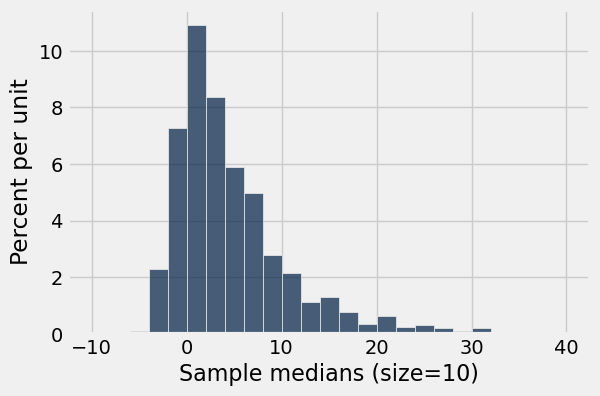

In [9]:
Table().with_column('Sample medians (size=10)', sample_medians).hist(bins=np.arange(-10,41,2))

In [10]:
sample_medians = make_array()

for i in np.arange(num_simulations):
    sample_medians = np.append(sample_medians, sample_median(50))

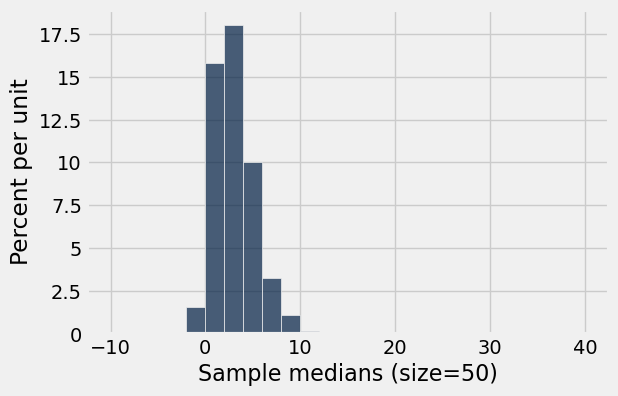

In [11]:
Table().with_column('Sample medians (size=50)', sample_medians).hist(bins=np.arange(-10,41,2))

#### Empirical Distributions of a Statistic (Overlayed)

Here we can see how changing the sample size impacts the empirical distribution of the statistic.

In [12]:
sample_medians_10 = make_array()
sample_medians_100 = make_array()
sample_medians_1000 = make_array()

num_simulations = 2000

for i in np.arange(num_simulations):
    new_median_10 = sample_median(10)
    sample_medians_10 = np.append(sample_medians_10, new_median_10)
    new_median_100 = sample_median(100)
    sample_medians_100 = np.append(sample_medians_100, new_median_100)
    new_median_1000 = sample_median(1000)
    sample_medians_1000 = np.append(sample_medians_1000, new_median_1000)

In [13]:
sample_medians = Table().with_columns('Size 10', sample_medians_10, 
                                      'Size 100', sample_medians_100,
                                      'Size 1000', sample_medians_1000)

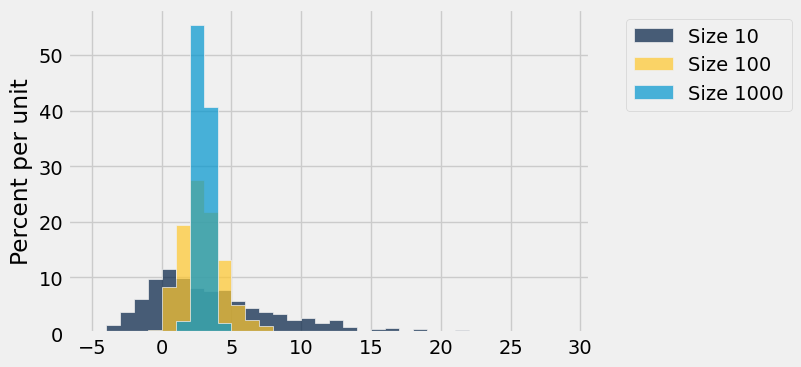

In [14]:
sample_medians.hist(bins = np.arange(-5, 30))

## Simulation of a Statistic 

We can take this idea and apply it to a new problem.  Let's look at the Billboard charts data in the 2010s, from lab 8. 

In [15]:
# Run this cell!
billboard = Table.read_table('billboard-2010.csv')
billboard.show(5)

Artists,Name,Weekly.rank,Peak.position,Weeks.on.chart,Week,Date,Genre,Features
"Lil Nas,",Old Town Road,1,1,7,2019-07-06,"April 5, 2019","Country,Atlanta,Alternative Country,Hip-Hop,Trap,Memes,R ...",Billy Ray Cyrus
Billie Eilish,Bad Guy,3,2,13,2019-07-06,"March 29, 2019","Hip-Hop,Dark Pop,House,Trap,Memes,Alternative Dance,Alte ...",nan
Khalid,Talk,4,3,20,2019-07-06,"February 7, 2019","Synth-Pop,Pop",nan
"Ed Sheeran, Justin Bieber",I Don't Care,5,2,7,2019-07-06,"May 10, 2019","Canada,UK,Dance,Dance-Pop,Pop",nan
Jonas Brothers,Sucker,6,1,17,2019-07-06,"March 1, 2019","Alternative Pop,Boy Band,Teen Pop,Pop-Rock,Pop",nan


#### Empirical Distributions of a Statistic

Let's say we want to look at the __*average number of weeks a song appears on the chart*__. 

First, we can calculate this for the entire data set. 

In [16]:
# (Population) Parameter
np.mean(billboard.column('Weeks.on.chart'))

13.167095433631822

In [17]:
# (Sample) Statistic 
np.mean(billboard.sample(100).column('Weeks.on.chart'))

13.44

Now, we will use the steps above to simulate a statistic - mean number of weeks on the chart.

* **Step 1: Decide which statistics to simulate**  In this case, we will examine the mean weeks on the chart.

* **Step 2: Define a function that returns one simulated value of the statistics** Draw a random sample of the sample size and compute the statistic of the sample.

* **Step 3: Decide how many simulated values to generate.** 

* **Step 4: Use a `for` loop to generate an array of simulated values** Create an empty array to collect the values. The body of the loop generates one simulated value of the statistic and appends it to the collection array.

In [18]:
def sample_mean(size):
    return np.median(billboard.sample(size).column('Weeks.on.chart'))

In [19]:
num_repetitions = 5000

sample_means = make_array()

for i in np.arange(num_repetitions):
    sample_means = np.append(sample_means, sample_mean(1000))

We can display the *empirical distribution of the statistic*. 

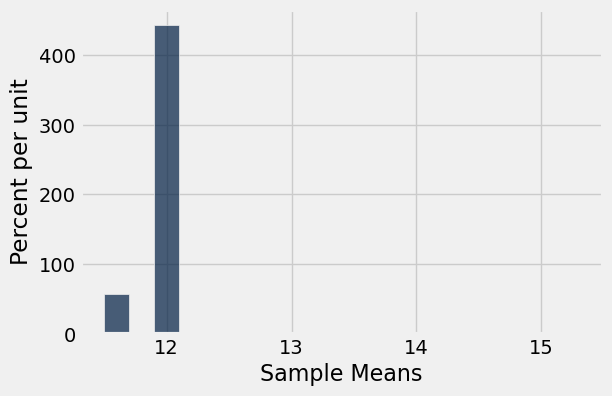

In [20]:
simulated_means = Table().with_column('Sample Means', sample_means)
simulated_means.hist(bins = np.arange(11.5,15.5, 0.2))

We can see that the sample mean is very likely to be ~13.2, which is close to the value of the population mean. 

<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>


## Swain vs. Alabama


Let's create the proportions of the population who are Black and White. 

In [21]:
population_proportions = make_array(.26, .74)
population_proportions

array([ 0.26,  0.74])

The function returns the empirical distribution of a particular sample.

In [22]:
sample_proportions(100, population_proportions)

array([ 0.17,  0.83])

If I run it again, you get another empirical distribution. 

We are going to be paying attention to the first number (the percentage black). 
The number we got in the observed juror panel was 8%

In [23]:
sample_proportions(100, population_proportions)

array([ 0.27,  0.73])

So, let's run this a lot of times and see if a number like 8 or lower comes up. 

Create a function that creates the sample, and returns the first number from the emprical distribution (the proportion black). 

In [24]:
def panel_proportion():
    return sample_proportions(100, population_proportions).item(0)

In [25]:
panel_proportion()

0.23

So, let's run this 10000 times and collect the information on the percentage of Blacks on each panel. 


We do this using the same code we have see above to simulate a statistic (proportion black).

Then, we can plot the results.

In [26]:
panels = make_array()

for i in np.arange(10000):
    new_panel = panel_proportion() * 100
    panels = np.append(panels, new_panel)

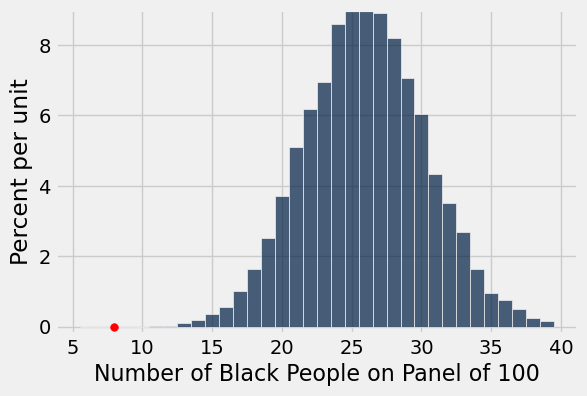

In [27]:
Table().with_column(
    'Number of Black People on Panel of 100', panels
).hist(bins=np.arange(5.5,40.))

# Plotting details; ignore this code
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

There is a theoretical probability here to get 10/100 or 24/100 or any of these values. 
This is really hard to calculate. 

Instead, we simulate this 10000 times to get a very good estimate of the theoretical distribution. 

And what do we see for this problem, that the juror panel had only 8 Black people on it was very, very unlikely outcome. It is not zero, but very close to zero.  


<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>

## Mendel and Pea Flowers

First, we can set up the predicted proportions with 75% purple-flowering peas. 

In [28]:
predicted_proportions = make_array(.75, .25)
sample_proportions(929, predicted_proportions)

array([ 0.73627557,  0.26372443])

What Mendel observed was 709 purple flowering peas out of 929. 

In [29]:
## Mendel had 929 plants, of which 709 had purple flowers
observed_purples = 709 / 929
observed_purples

0.7631862217438106

What he actually observed was 76.3% and expected 75%.  

Is this reasonable for a sample with 929. 

Let's set up the simulation. 
Create a function to return the statistic value on the sample. 

**It is very important that the sample size is the same**   
*we are simulating in the same conditions as the sample was generated*

In [30]:
def purple_flowers():
    return sample_proportions(929, predicted_proportions).item(0) * 100

In [31]:
purple_flowers()

76.21097954790098

In [32]:
purples = make_array()

for i in np.arange(10000):
    new_purple = purple_flowers()
    purples = np.append(purples, new_purple)

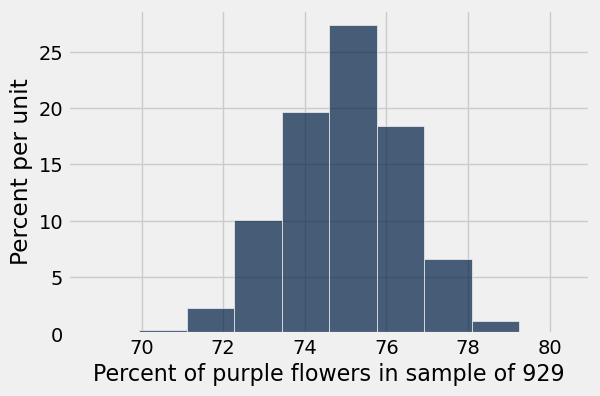

In [33]:
Table().with_column('Percent of purple flowers in sample of 929', purples).hist()

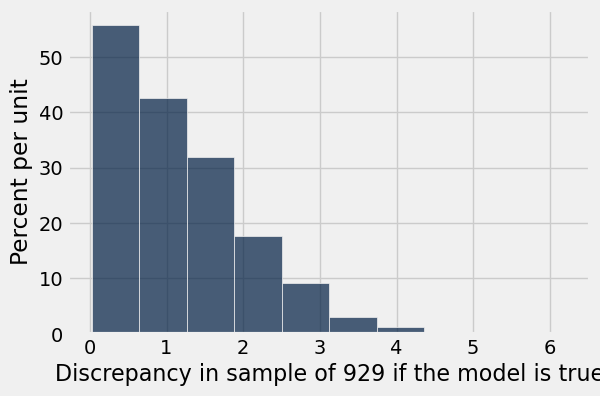

In [34]:
Table().with_column('Discrepancy in sample of 929 if the model is true', abs(purples- 75)).hist()

In [35]:
abs(observed_purples * 100 - 75)

1.318622174381062

<br><br><br><br>

---

<center> return to slides </center>

---

<br><br>